<a href="https://colab.research.google.com/github/thegurdian/ML/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/diabetes.csv")   # Change path if needed

print("Shape:", df.shape)

df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
print("Missing Values")

null_values = df.isnull().sum()

print(null_values)

# Total Missing Values
print("\nTotal Missing Values :", null_values.sum())

Missing Values
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total Missing Values : 0


In [7]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_count = (df[zero_columns] == 0).sum()

print(zero_count)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [8]:
corr = df.corr(numeric_only=True)

corr["Outcome"].sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


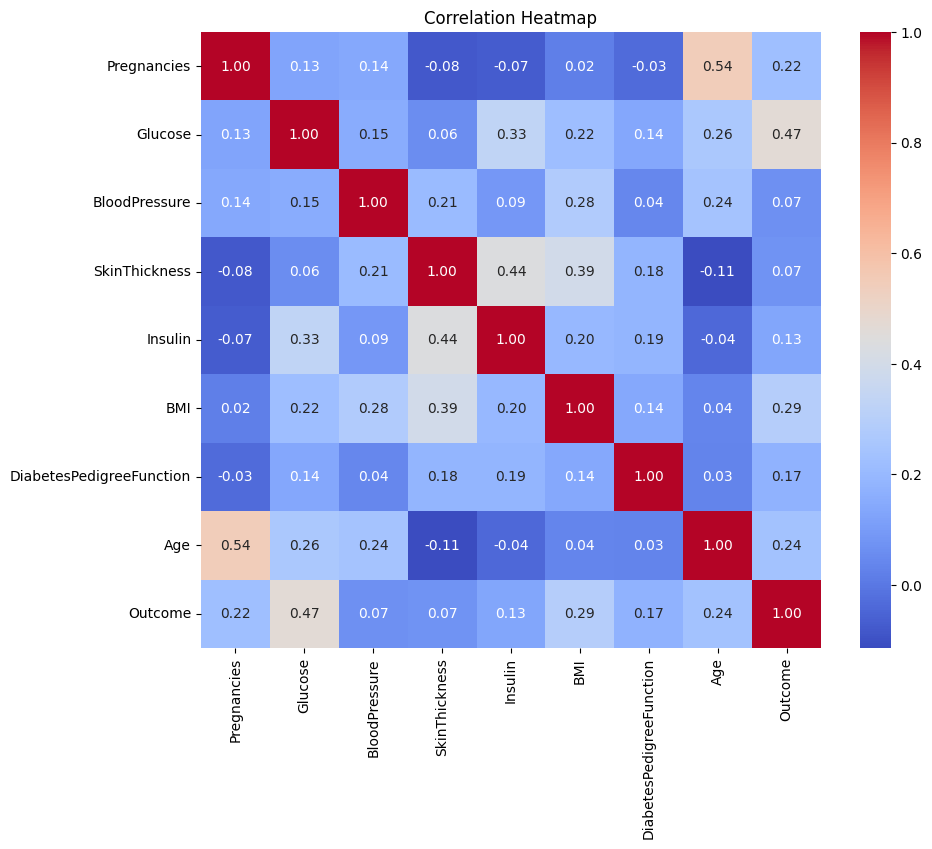

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

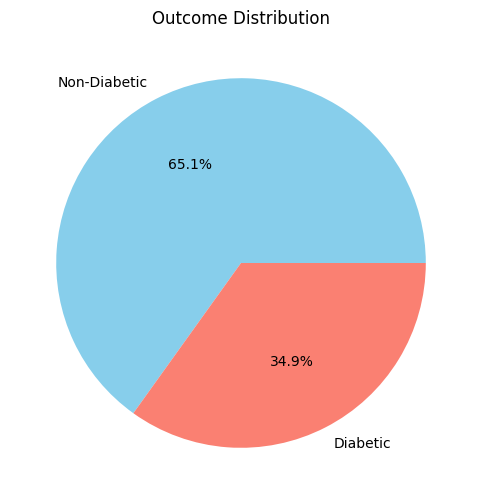

In [10]:
plt.figure(figsize=(6,6))

df["Outcome"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Non-Diabetic","Diabetic"],
    colors=["skyblue","salmon"]
)

plt.ylabel("")

plt.title("Outcome Distribution")

plt.show()

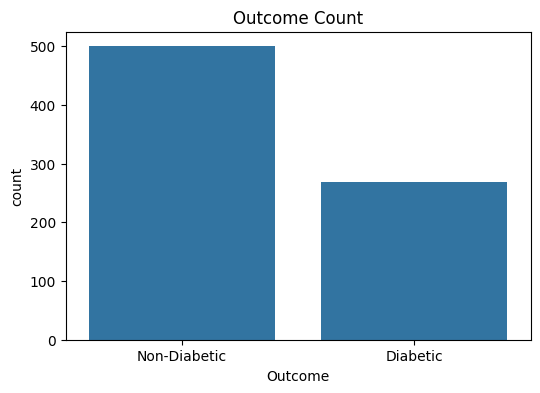

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Outcome"
)

plt.xticks([0,1],["Non-Diabetic","Diabetic"])

plt.title("Outcome Count")

plt.show()

In [12]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
columns_to_impute = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
X_train[columns_to_impute] = X_train[columns_to_impute].replace(0, np.nan)

X_test[columns_to_impute] = X_test[columns_to_impute].replace(0, np.nan)
imputer = SimpleImputer(strategy="median")
X_train[columns_to_impute] = imputer.fit_transform(
    X_train[columns_to_impute]
)

X_test[columns_to_impute] = imputer.transform(
    X_test[columns_to_impute]
)

In [15]:
mi = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_train.columns
).sort_values(ascending=False)

print(mi_scores)

Glucose                     0.117706
BMI                         0.093590
Age                         0.062202
Insulin                     0.043321
Pregnancies                 0.038053
SkinThickness               0.033670
BloodPressure               0.020999
DiabetesPedigreeFunction    0.006189
dtype: float64


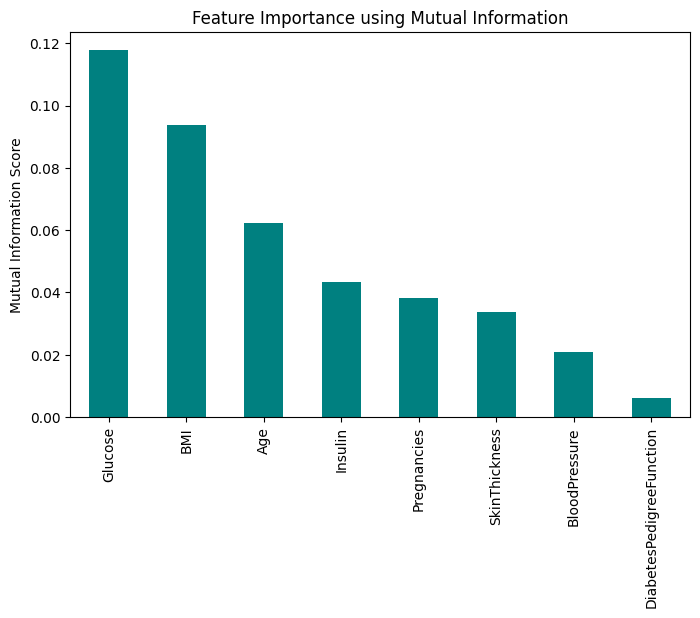

In [16]:
plt.figure(figsize=(8,5))

mi_scores.plot(
    kind="bar",
    color="teal"
)

plt.ylabel("Mutual Information Score")

plt.title("Feature Importance using Mutual Information")

plt.show()

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

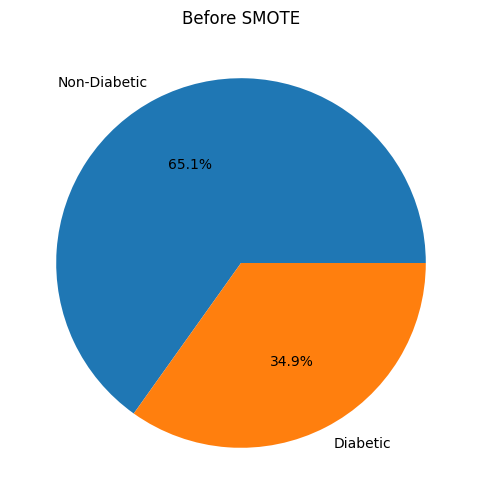

In [18]:
plt.figure(figsize=(6,6))

pd.Series(y_train).value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Non-Diabetic","Diabetic"]
)

plt.title("Before SMOTE")

plt.ylabel("")

plt.show()

In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

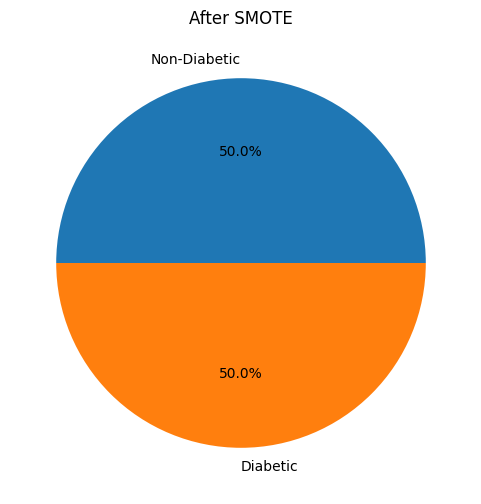

In [20]:
pd.Series(y_train_smote).value_counts()
plt.figure(figsize=(6,6))

pd.Series(y_train_smote).value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Non-Diabetic","Diabetic"]
)

plt.title("After SMOTE")

plt.ylabel("")

plt.show()

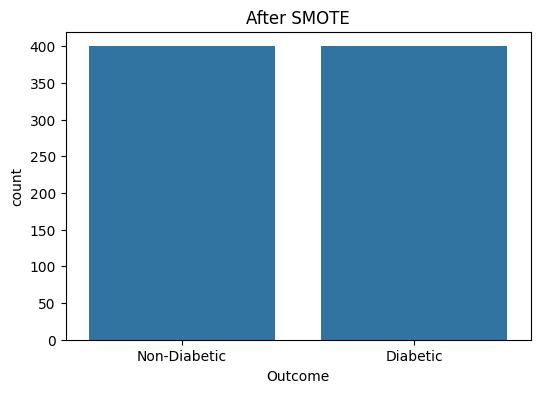

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.xticks([0,1],["Non-Diabetic","Diabetic"])

plt.title("After SMOTE")

plt.show()

In [22]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [23]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),

    "Support Vector Machine": SVC(random_state=42),

    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [24]:
results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

Logistic Regression
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1 Score : 0.6087

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154

Confusion Matrix
[[74 26]
 [19 35]]


Support Vector Machine
Accuracy : 0.7273
Precision: 0.5968
Recall   : 0.6852
F1 Score : 0.6379

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       100
           1       0.60      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154

Confusion Matrix
[[75 25]
 [17 37]]


K-Nearest Neighbors
Accuracy : 0.6948

In [25]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
5,Gradient Boosting,0.766234,0.640625,0.759259,0.694915
4,Random Forest,0.753247,0.633333,0.703704,0.666667
1,Support Vector Machine,0.727273,0.596774,0.685185,0.637931
6,XGBoost,0.733766,0.614035,0.648148,0.630631
2,K-Nearest Neighbors,0.694805,0.550725,0.703704,0.617886
0,Logistic Regression,0.707792,0.573770,0.648148,0.608696
3,Decision Tree,0.701299,0.568966,0.611111,0.589286


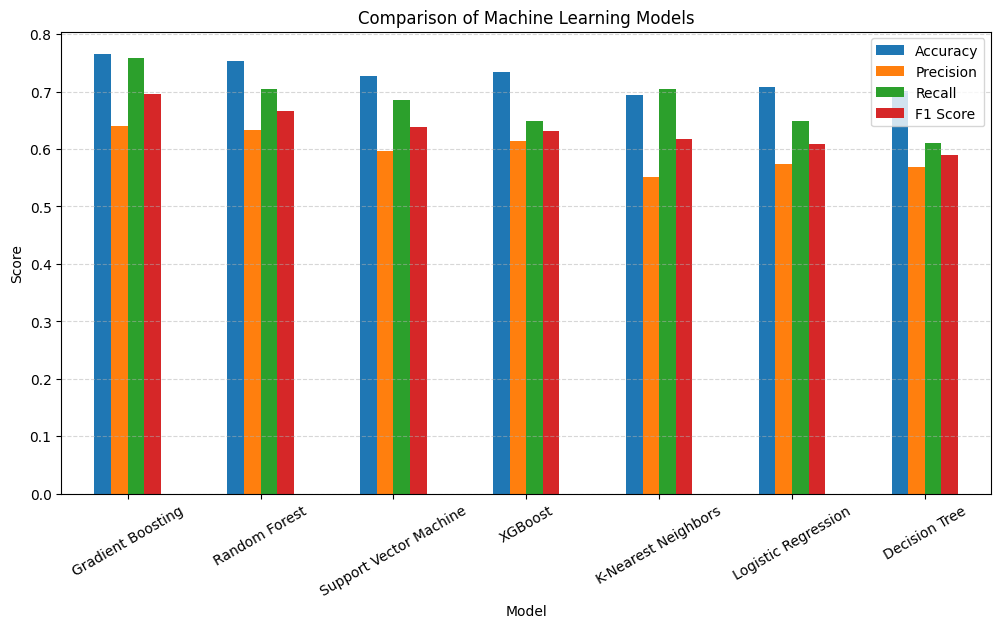

In [26]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd

In [28]:
lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", lr_grid.best_params_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [29]:
rf_params = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
    "max_features":["sqrt","log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_smote,y_train_smote)

print(rf_grid.best_params_)

{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [30]:
svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_smote, y_train_smote)

print(svm_grid.best_params_)

{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [31]:
knn_params = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train_smote,y_train_smote)

print(knn_grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}


In [32]:
dt_params = {
    "criterion": ["gini","entropy"],
    "max_depth": [3,5,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train_smote,y_train_smote)

print(dt_grid.best_params_)

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [33]:
gb_params = {
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.1],
    "max_depth":[3,5],
    "subsample":[0.8,1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(X_train_smote,y_train_smote)

print(gb_grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [34]:
xgb_params = {
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1],
    "subsample":[0.8,1.0],
    "colsample_bytree":[0.8,1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_smote,y_train_smote)

print(xgb_grid.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [35]:
best_models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report")
    print(classification_report(y_test,y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test,y_pred))

Logistic Regression
Accuracy : 0.7143
Precision: 0.5806
Recall   : 0.6667
F1 Score : 0.6207

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154

Confusion Matrix
[[74 26]
 [18 36]]
SVM
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1 Score : 0.6087

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154

Confusion Matrix
[[74 26]
 [19 35]]
KNN
Accuracy : 0.7078
Precision: 0.5652
Recall   : 0.7222
F1

In [36]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="F1 Score",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.753247,0.621212,0.759259,0.683333
1,Random Forest,0.753247,0.629032,0.722222,0.672414
2,Decision Tree,0.675325,0.521739,0.888889,0.657534
3,KNN,0.707792,0.565217,0.722222,0.634146
4,Gradient Boosting,0.727273,0.600000,0.666667,0.631579
5,Logistic Regression,0.714286,0.580645,0.666667,0.620690
6,SVM,0.707792,0.573770,0.648148,0.608696


In [37]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
results = []

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean()
    })

In [42]:
cv_results = pd.DataFrame(results)

cv_results = cv_results.sort_values(
    by="F1 Score",
    ascending=False
)

cv_results

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.82000,0.803763,0.8475,0.823319
2,KNN,0.79500,0.755041,0.8825,0.811732
6,XGBoost,0.80250,0.793773,0.8225,0.805360
1,SVM,0.78875,0.783245,0.8075,0.792058
5,Gradient Boosting,0.78375,0.766318,0.8175,0.789745
3,Decision Tree,0.73625,0.729575,0.7550,0.739202
0,Logistic Regression,0.74000,0.758830,0.7050,0.729123
